# Fake vs Real News Classification
TF-IDF + Logistic Regression / Naive Bayes / Linear SVM on the ISOT Fake and Real News dataset.

Run this notebook from the `notebooks/` folder after placing `Fake.csv` and `True.csv` in `data/`.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

from src.preprocess import load_raw, prepare, clean_text
from src.models import build_models, make_pipeline, TEST_SIZE, RANDOM_STATE, DEPLOYED_MODEL
sns.set_theme(style='whitegrid')

## 1. Load and label
fake = 0, real = 1. Merge and shuffle.

In [2]:
df = load_raw(data_dir='../data')
print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## 2. Explore the data

In [3]:
print('Nulls:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated(subset=['title','text']).sum())
print('Empty text rows:', (df['text'].str.strip() == '').sum())
print('\nClass counts:\n', df['label'].map({0:'Fake',1:'Real'}).value_counts())

Nulls:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate rows: 5793
Empty text rows: 631

Class counts:
 label
Fake    23481
Real    21417
Name: count, dtype: int64


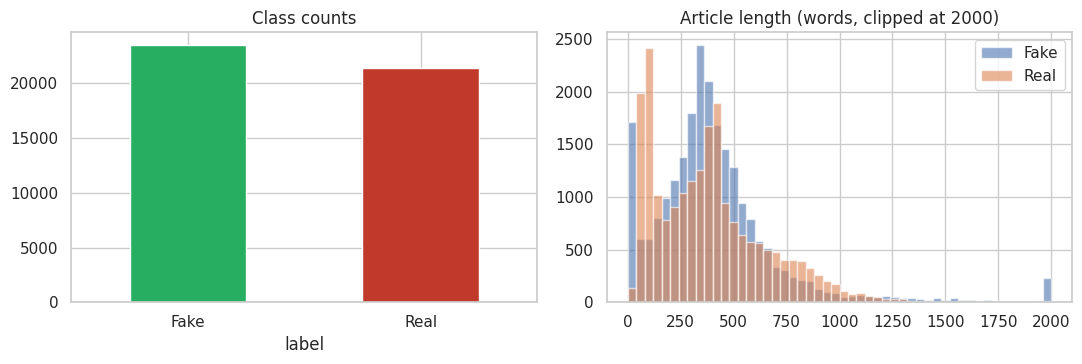

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
df['label'].map({0:'Fake',1:'Real'}).value_counts().plot.bar(ax=ax[0], color=['#27ae60','#c0392b'])
ax[0].set_title('Class counts'); ax[0].tick_params(axis='x', rotation=0)
df['len'] = df['text'].str.split().str.len()
for lab, name in [(0,'Fake'),(1,'Real')]:
    ax[1].hist(df.loc[df.label==lab,'len'].clip(upper=2000), bins=50, alpha=0.6, label=name)
ax[1].set_title('Article length (words, clipped at 2000)'); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Leakage checks
The `subject` column separates the classes almost perfectly, so it is dropped. The `(Reuters)` dateline appears only in real articles, so it is stripped.

In [5]:
print(pd.crosstab(df['subject'], df['label'].map({0:'Fake',1:'Real'})))
print()
real = df[df.label == 1]
fake = df[df.label == 0]
print('Real articles containing "(Reuters)":', real['text'].str.contains(r'\(Reuters\)').mean().round(3))
print('Fake articles containing "(Reuters)":', fake['text'].str.contains(r'\(Reuters\)').mean().round(3))

label            Fake   Real
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6841      0
politicsNews        0  11272
worldnews           0  10145

Real articles containing "(Reuters)": 0.992
Fake articles containing "(Reuters)": 0.0


## 4. Clean text
Drop subject/date, remove empty rows and duplicates, then: strip dateline, lowercase, remove URLs/punctuation/numbers, remove stopwords, lemmatize. Title and body are combined.

In [6]:
data = prepare(df)
print(data.shape)
print(data['label'].value_counts())
print('\nBefore:', data['raw'].iloc[0][:250])
print('\nAfter :', data['clean'].iloc[0][:250])

(38376, 6)
label
1    20922
0    17454
Name: count, dtype: int64

Before: Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution. 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris B

After : ben stein call th circuit court committed coup tat constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show 


## 5. Train/test split (80/20, stratified)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    data['clean'], data['label'], test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=data['label'])
print(len(X_train), len(X_test))

30700 7676


## 6. Vectorize and train
Settings live in `src/models.py` (TF-IDF with unigrams + bigrams and 10,000 features, inside each pipeline so it is fit on training data only). The notebook and `src/train.py` use the same settings.

In [8]:
models = build_models()
rows = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows[name] = dict(accuracy=accuracy_score(y_test, pred), precision=precision_score(y_test, pred),
                      recall=recall_score(y_test, pred), f1=f1_score(y_test, pred))
results = pd.DataFrame(rows).T.round(4)
results

,accuracy,precision,recall,f1
Logistic Regression,0.9914,0.9902,0.9940,0.9921
Naive Bayes,0.9574,0.9633,0.9584,0.9608
Linear SVM,0.9922,0.9912,0.9945,0.9928


## 7. Evaluate

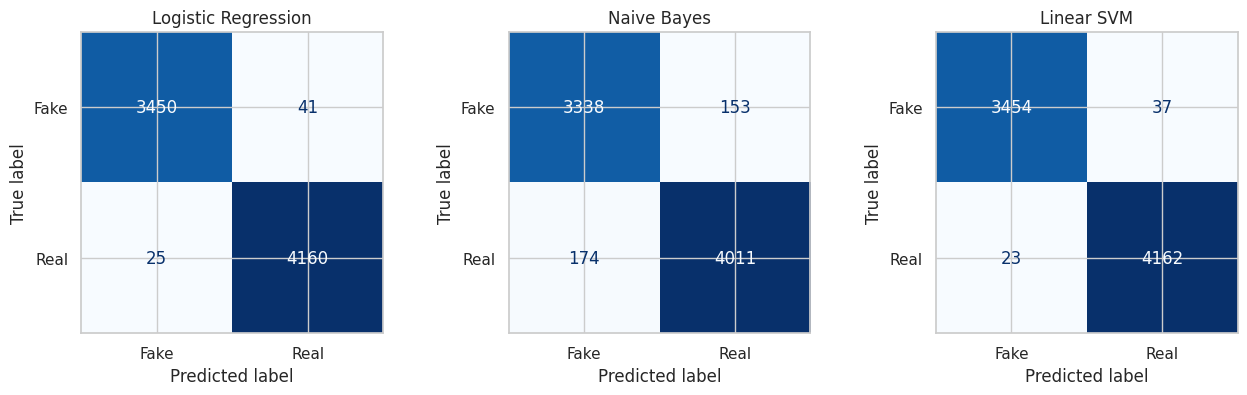

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pipe.predict(X_test),
        display_labels=['Fake','Real'], cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

In [10]:
print(classification_report(y_test, models['Logistic Regression'].predict(X_test), target_names=['Fake','Real']))

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3491
        Real       0.99      0.99      0.99      4185

    accuracy                           0.99      7676
   macro avg       0.99      0.99      0.99      7676
weighted avg       0.99      0.99      0.99      7676



5-fold cross-validation on the training set (Logistic Regression). The vectorizer is refit inside every fold.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(build_models()[DEPLOYED_MODEL], X_train, y_train,
                         cv=cv, scoring='f1', n_jobs=-1)
print('F1 per fold:', scores.round(4))
print('Mean F1: %.4f (+/- %.4f)' % (scores.mean(), scores.std()))

F1 per fold: [0.9909 0.9924 0.9917 0.9918 0.9912]
Mean F1: 0.9916 (+/- 0.0005)


## 8. Explain the model
Top words by logistic regression coefficient. Positive = pushes toward REAL, negative = toward FAKE.

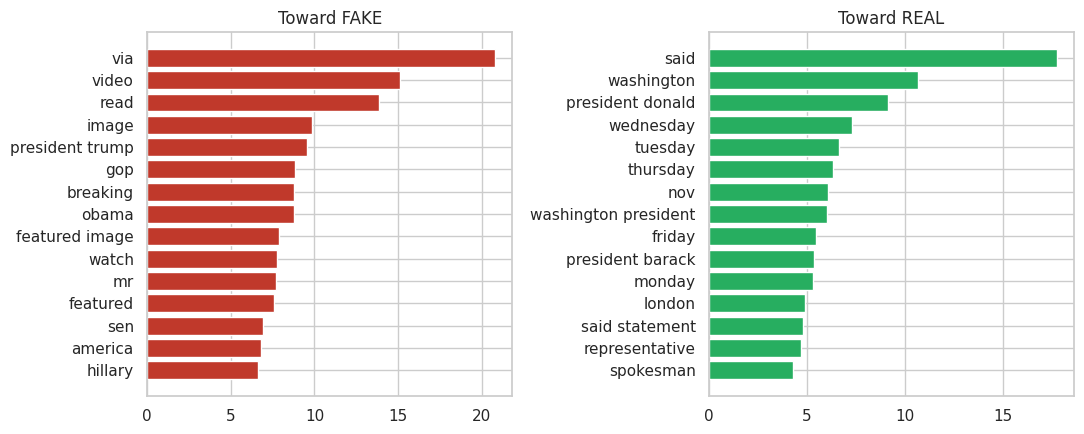

In [12]:
lr = models['Logistic Regression']
names = np.array(lr.named_steps['tfidf'].get_feature_names_out())
coef = lr.named_steps['clf'].coef_[0]
order = np.argsort(coef)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(names[order[:15]][::-1], -coef[order[:15]][::-1], color='#c0392b'); axes[0].set_title('Toward FAKE')
axes[1].barh(names[order[::-1][:15]][::-1], coef[order[::-1][:15]][::-1], color='#27ae60'); axes[1].set_title('Toward REAL')
plt.tight_layout(); plt.show()

Many top words are style signals of the sources (weekday names, `said`, `via`, `featured image`), not proof of truth. That is why accuracy is so high on this dataset and why it will drop on news from other outlets.

## 9. Try it on a new example

In [13]:
from src.explain import top_terms
text = "BREAKING: You won't believe what Obama just did! Watch this video and share this image via our page."
cleaned = clean_text(text)
p_real = lr.predict_proba([cleaned])[0][1]
print('P(real) = %.3f ->' % p_real, 'REAL' if p_real >= 0.5 else 'FAKE')
print(top_terms(lr, cleaned, 5))

P(real) = 0.000 -> FAKE
([('share', 0.09567805054301765)], [('via', 4.2299743411974), ('video', 3.3498650140593833), ('breaking', 3.299924522491101), ('watch', 2.045109075968921), ('image', 2.0368878816176057)])


## 10. Save the model
The final model is saved by `python -m src.train` to `models/fake_news_pipeline.joblib` (used by `app.py`).

## Limitations
- Both classes come from a small set of outlets, mostly 2016-2017 US politics.
- The model learns writing style, not facts.
- Next step: test on a second dataset (for example WELFake) to measure the drop on unseen sources.